In [ ]:
#imports and setup
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append("../src")
from db_connection import get_engine

engine = get_engine()

In [2]:
customers = pd.read_sql("SELECT * FROM clean_customers", engine)
transactions = pd.read_sql("SELECT * FROM clean_transactions", engine)
feedback = pd.read_sql("SELECT * FROM clean_feedback", engine)

**Customer Analysis (Churn)**

In [3]:
customers['churn'].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

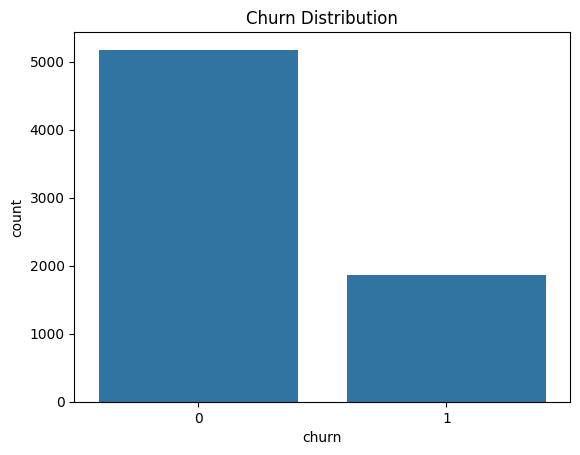

In [ ]:
#churn distribution
sns.countplot(x='churn', data=customers)
plt.title("Churn Distribution")
plt.show()

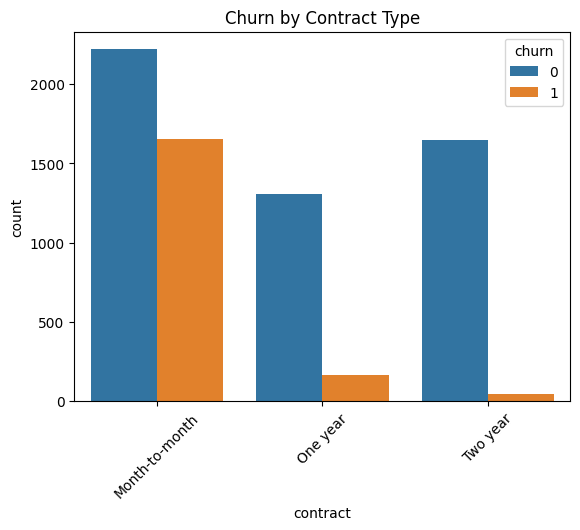

In [5]:
#churn by contact type
sns.countplot(x='contract', hue='churn', data=customers)
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)
plt.show()

those with a monthly subscription are most likely to cancel the contract than those with 1 or 2 year contracts

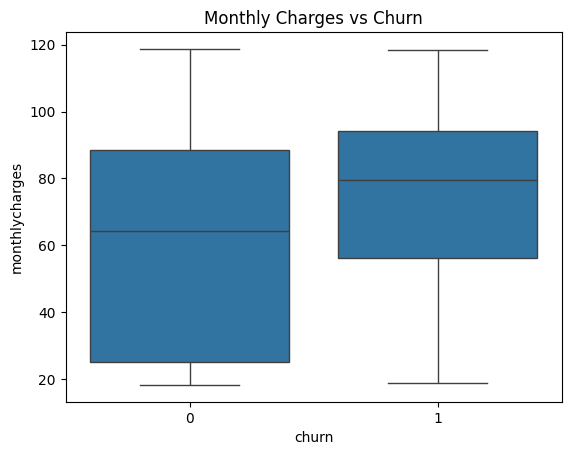

In [6]:
#churn by monthly charges
sns.boxplot(x='churn', y='monthlycharges', data=customers)
plt.title("Monthly Charges vs Churn")
plt.show()

prices between 80 and 100 are considered expensive and customers are most likely cancelling when paying for higher subscriptions

**Transactions Analysis (Risk)**

In [7]:
#Fraud distribution
transactions['class'].value_counts()

class
0    49871
1       83
Name: count, dtype: int64

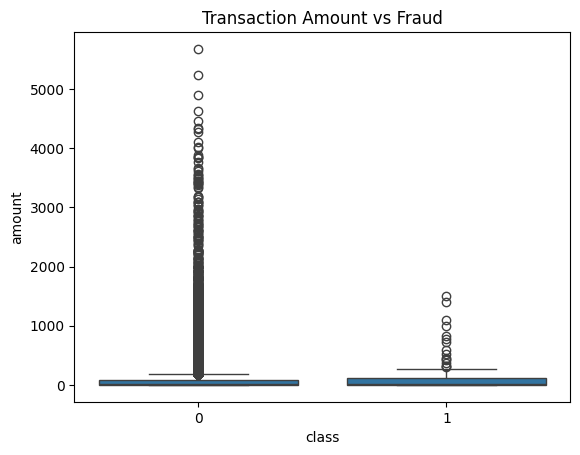

In [8]:
#fraud vs amount
sns.boxplot(x='class', y='amount', data=transactions)
plt.title("Transaction Amount vs Fraud")
plt.show()

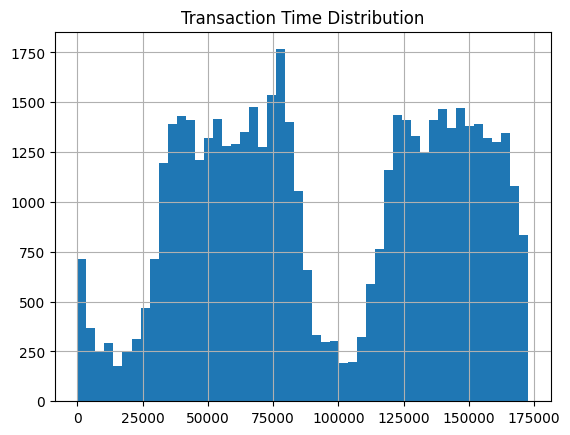

In [9]:
#Pattern
transactions['time'].hist(bins=50)
plt.title("Transaction Time Distribution")
plt.show()

**Feedback Analysis (NLP)**

In [10]:
#sentiment distribution
feedback['sentiment'].value_counts()

sentiment
1.0    443777
0.0     82037
Name: count, dtype: int64

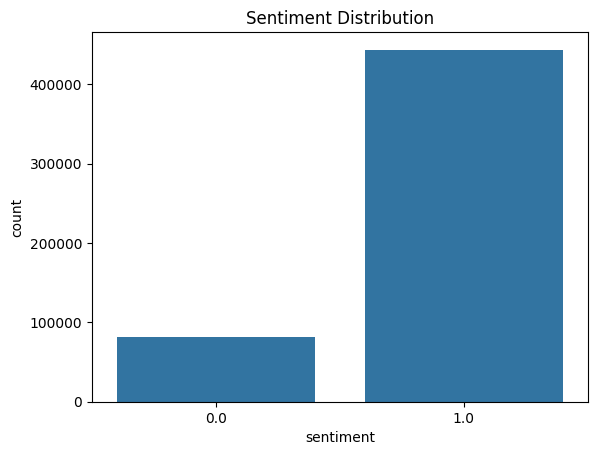

In [11]:
sns.countplot(x='sentiment', data=feedback)
plt.title("Sentiment Distribution")
plt.show()

overall customers are giving positive feedbacks

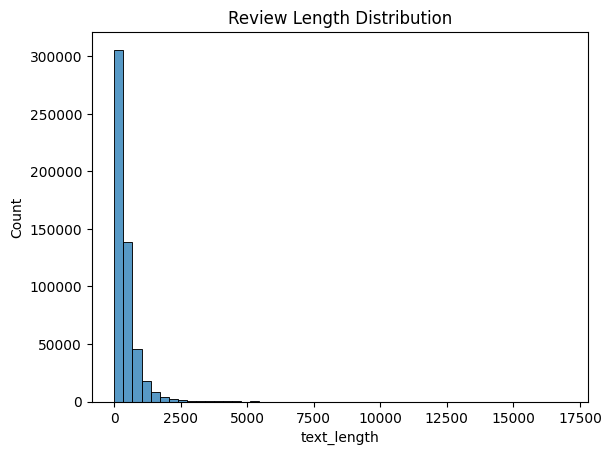

In [12]:
#text length
feedback['text_length'] = feedback['text'].apply(len)

sns.histplot(feedback['text_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

**Correlation Analysis**

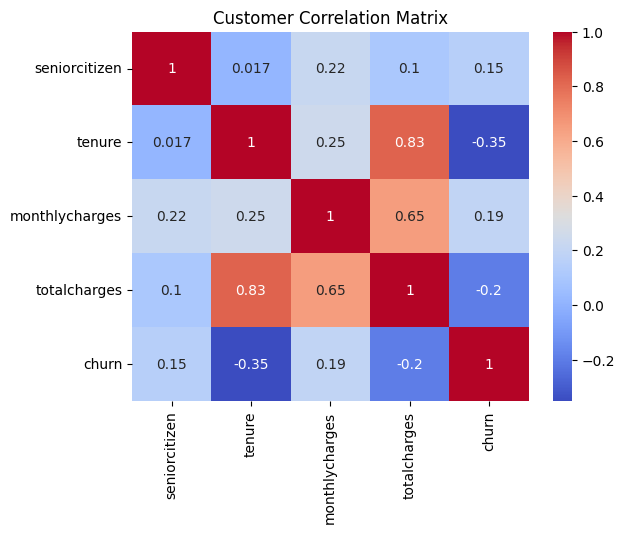

In [13]:
#correlation matrix
corr = customers.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Customer Correlation Matrix")
plt.show()

tenure is linked to totalcharges for some reason idk why lol

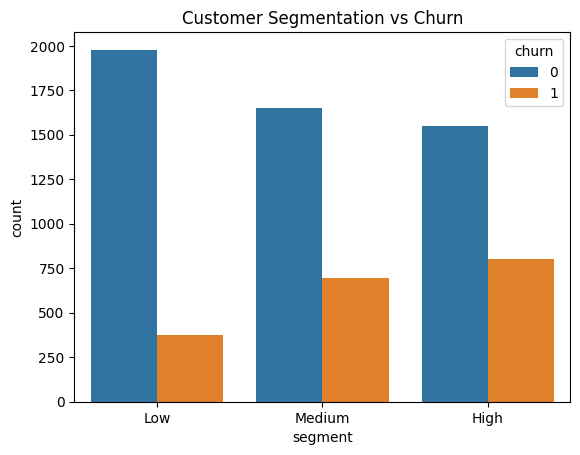

In [ ]:
#simple segmentation (cuz why not?)
customers['segment'] = pd.qcut(customers['monthlycharges'], q=3, labels=['Low', 'Medium', 'High'])

sns.countplot(x='segment', hue='churn', data=customers)
plt.title("Customer Segmentation vs Churn")
plt.show()